## Data insights

Interpretation of human behavior depends on who writes it.

Analysis behind the write-up at [emilinelabbe.github.io/who-decides-what-psych-says](https://emilinelabbe.github.io/who-decides-what-psych-says/). Loads `data/processed/publication_data.csv` from `00_data_processing.ipynb`, and writes the PNGs in `figures/` plus the Plotly specs behind `docs/index.html`.

Figures and findings cover 2011-2022 unless noted; the time series runs 2003-2022.

### Findings

1. **Among large science producers, psychology takes up more room in WEIRD countries.** Every WEIRD country in the top 15 devotes at least 2.2% of its output to psychology, and every non-WEIRD country 1.3% or less.
2. **The US writes more psychology than any other country.** It produces 33.8% of the world's psychology, against 17.4% of all science and 4.3% of world population.
3. **Psychology can be a small part of a country's science and still account for a large share of the world's psychology.** China ranks fifth in psychology volume on a psychology share under half a percent.
4. **Psychology's center of production is shifting away from the US and its WEIRD peers.** The US share fell from 46.8% to 27.7% between 2003 and 2022 while China's rose from 0.7% to 11.1%.

Sections below follow that order, then add the supplementary PPML models cited in the write-up's Data and methods.

### Setup


In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import statsmodels.api as sm

from figure_style import (
    BG, LEAD, ALT, UK_C, CA_C, DE_C, FAINT, MAP_SCALE, GRID,
    SANS, PAD, HOVER,
    titled, write_chart_data, short_number, darken, gradient_color,
)

# GitHub's notebook renderer cannot run Plotly's JS. 
# Emit a static PNG alongside the interactive figure; 
# JupyterLab and VS Code stay interactive
pio.renderers.default = "plotly_mimetype+png"

### Figure guidelines

Palette, Plotly template, and helpers are shared through `figure_style.py`; the swatches printed above mirror `docs/style.css`. Site figures are built bare and take their titles from `index.html`; `titled()` puts titles back on for the PNGs in `figures/`.

## Coverage and window

Cross-sectional summaries use 2011-2022, the most recent twelve years. Publication counts run 2003-2022 and the time series uses the full range.


In [2]:
merged_data = pd.read_csv("../data/processed/publication_data.csv")

wdi_cols = [c for c in merged_data.columns if c not in
            ['iso_alpha', 'Year', 'Publications', 'Country', 'data_source_flag']]
years_with_wdi = merged_data.loc[merged_data[wdi_cols].notna().any(axis=1), 'Year']

print(f"Country-year rows: {len(merged_data)}")
print(f"Distinct countries: {merged_data['Country'].nunique()}")
print(f"Years: {merged_data['Year'].min()}-{merged_data['Year'].max()}")
print(f"Years with WDI coverage: {years_with_wdi.min()}-{years_with_wdi.max()} ({years_with_wdi.nunique()} years)")

Country-year rows: 4020
Distinct countries: 201
Years: 2003-2022
Years with WDI coverage: 2003-2022 (20 years)


In [3]:
mean_cols = [
    'GDP_per_capita', 'GDP_per_capita_PPP', 'GNI_per_capita_PPP', 'Population',
    'Tertiary_enrollment_pct', 'RnD_expenditure_pct', 'Researchers_per_million',
    'Education_expenditure_pct', 'Tertiary_education_expenditure_pct',
    'Urban_population_pct', 'Sci_tech_articles', 'Internet_users_pct',
]

country_summary = merged_data.groupby(['iso_alpha', 'Country'], as_index=False).agg(
    Publications=('Publications', lambda x: x.sum(min_count=1)),
    SE_articles_total=('SE_articles_total', lambda x: x.sum(min_count=1)),
    n_years=('Year', 'nunique'),
    data_source_flag=('data_source_flag', 'first'),
    **{col: (col, 'mean') for col in mean_cols},
)

country_summary['psych_share'] = country_summary['Publications'] / country_summary['SE_articles_total']
country_summary['log_publications'] = np.log1p(country_summary['Publications'])

print(f"Countries: {len(country_summary)}")
print(f"Years: {merged_data['Year'].min()}-{merged_data['Year'].max()}")
print(f"Total psychology publications: {country_summary['Publications'].sum():,.0f}")
print(f"Years covered per country: {country_summary['n_years'].min()}-{country_summary['n_years'].max()} "
      f"(median {country_summary['n_years'].median():.0f})")
print(f"Zero publications: {(country_summary['Publications'] == 0).sum()}")
print(f"Missing publications entirely: {country_summary['Publications'].isna().sum()}")
print(f"Missing GDP_per_capita: {country_summary['GDP_per_capita'].isna().sum()}")

Countries: 201
Years: 2003-2022
Total psychology publications: 815,406
Years covered per country: 20-20 (median 20)
Zero publications: 10
Missing publications entirely: 0
Missing GDP_per_capita: 4


In [4]:
window = merged_data[merged_data['Year'].between(2011, 2022)]

country_summary_11_22 = window.groupby(['iso_alpha', 'Country'], as_index=False).agg(
    Publications=('Publications', lambda x: x.sum(min_count=1)),
    SE_articles_total=('SE_articles_total', lambda x: x.sum(min_count=1)),
    n_years=('Year', 'nunique'),
    data_source_flag=('data_source_flag', 'first'),
    **{col: (col, 'mean') for col in mean_cols},
)

country_summary_11_22['psych_share'] = (
    country_summary_11_22['Publications'] / country_summary_11_22['SE_articles_total'])
country_summary_11_22['log_publications'] = np.log1p(country_summary_11_22['Publications'])

print(f"Countries in 2011-2022 summary: {len(country_summary_11_22)}")
print(f"Total psychology publications (2011-2022): {country_summary_11_22['Publications'].sum():,.0f}")
print(f"Zero publications: {(country_summary_11_22['Publications'] == 0).sum()}")

Countries in 2011-2022 summary: 201
Total psychology publications (2011-2022): 596,911
Zero publications: 12


## Where psychology is written


### Distribution across countries


In [5]:
nonzero = country_summary_11_22['Publications'] > 0
q1, q2, q3 = country_summary_11_22.loc[nonzero, 'Publications'].quantile([0.25, 0.5, 0.75])
median = country_summary_11_22['Publications'].median()
plot_min = country_summary_11_22['Publications'].min()
plot_max = country_summary_11_22['Publications'].max()

print(f"zero contributions share: {(~nonzero).mean():.2%}")
print(f"min: {plot_min}, q1: {q1}, median (all): {median}, q2 (nonzero): {q2}, q3: {q3}, max: {plot_max}")

country_summary_11_22['quartile'] = 'Zero publications'
country_summary_11_22.loc[nonzero, 'quartile'] = pd.qcut(
    country_summary_11_22.loc[nonzero, 'Publications'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print(f"\nCountries per quartile:\n{country_summary_11_22['quartile'].value_counts()}")

top_quartile = country_summary_11_22.sort_values('Publications', ascending=False).reset_index(drop=True)
bottom_quartile = country_summary_11_22[country_summary_11_22['Publications'] > 0].sort_values('Publications').reset_index(drop=True)

print(f"\nTop 5 contributors:\n{top_quartile.iloc[:5, :3]}")
print(f"\nBottom 5 contributors, non-zero:\n{bottom_quartile.iloc[:5, :3]}\n")

print(top_quartile[top_quartile['Country'] == 'India'].iloc[:, :3])


zero contributions share: 5.97%
min: 0.0, q1: 6.17, median (all): 34.99, q2 (nonzero): 45.41, q3: 700.51, max: 201664.58000000002

Countries per quartile:
quartile
Q1                   48
Q2                   47
Q3                   47
Q4                   47
Zero publications    12
Name: count, dtype: int64

Top 5 contributors:
  iso_alpha         Country  Publications
0       USA   United States     201664.58
1       GBR  United Kingdom      49574.46
2       DEU         Germany      38102.80
3       CAN          Canada      29663.27
4       CHN           China      27903.16

Bottom 5 contributors, non-zero:
  iso_alpha       Country  Publications
0       TUV        Tuvalu          0.05
1       MDV      Maldives          0.10
2       COM       Comoros          0.20
3       COK  Cook Islands          0.22
4       VUT       Vanuatu          0.40

   iso_alpha Country  Publications
26       IND   India       3704.69


### The US share


In [6]:
world_total_psych = country_summary_11_22['Publications'].sum()
us = country_summary_11_22.loc[country_summary_11_22['Country'] == 'United States', 'Publications'].values[0]
print(f"world total: {world_total_psych:,.0f}")
print(f"US share: {us / world_total_psych:.1%}")

world_pop = country_summary_11_22['Population'].sum()
us_pop = country_summary_11_22.loc[country_summary_11_22['Country'] == 'United States', 'Population'].values[0]
print(f"US share of population: {us_pop / world_pop:.1%}\n")

non_us = country_summary_11_22[country_summary_11_22['Country'] != 'United States'].sort_values('Publications', ascending=False)

for rank, (_, row) in enumerate(non_us[:4].iterrows(), start=2):
    ratio = us / row['Publications']
    pop_share = row['Population'] / world_pop
    pub_share = row['Publications'] / world_total_psych
    print(f"US is {ratio:.1f}x {row['Country']} (#{rank}), who has {pub_share:.1%} of world publications "
          f"and {pop_share:.1%} of world population")

top_5_psych = us + top_quartile[1:5]['Publications'].sum()
print(f"\ntop 5 combined: {top_5_psych / world_total_psych:.1%} of world publications")

world total: 596,911
US share: 33.8%
US share of population: 4.3%

US is 4.1x United Kingdom (#2), who has 8.3% of world publications and 0.9% of world population
US is 5.3x Germany (#3), who has 6.4% of world publications and 1.1% of world population
US is 6.8x Canada (#4), who has 5.0% of world publications and 0.5% of world population
US is 7.2x China (#5), who has 4.7% of world publications and 18.4% of world population

top 5 combined: 58.1% of world publications


In [ ]:
# The other end of the distribution for the same period
tail = country_summary_11_22.set_index('Country')['Publications']

for cut in [100, 500, 1000]:
    below = tail[tail < cut]
    print(f"countries under {cut:>5,} publications: {len(below):3d} "
          f"({below.sum() / world_total_psych:.2%} of world psychology)")

smaller_half = tail.nsmallest(len(tail) // 2)
print(f"\nsmaller half of countries combined: {smaller_half.sum():,.0f} publications "
      f"({smaller_half.sum() / world_total_psych:.3%} of world)")
print(f"United States alone: {tail['United States']:,.0f} "
      f"({tail['United States'] / world_total_psych:.1%} of world)")

countries under   100 publications: 120 (0.34% of world psychology)
countries under   500 publications: 150 (1.47% of world psychology)
countries under 1,000 publications: 158 (2.36% of world psychology)

smaller half of countries combined: 784 publications (0.131% of world)
United States alone: 201,665 (33.8% of world)


### All science and engineering subjects

Same aggregation over every S&E field, for comparison against the psychology counts above.


In [8]:
top_quartile_all_SE = country_summary_11_22.sort_values('SE_articles_total', ascending=False).reset_index(drop=True)

print(f"\nTop 5 contributors, all SE subjects:\n{top_quartile_all_SE[:5].loc[:, ['Country','SE_articles_total']]}")



Top 5 contributors, all SE subjects:
         Country  SE_articles_total
0          China         6192884.71
1  United States         5324328.63
2          India         1442145.44
3        Germany         1322304.22
4          Japan         1263777.51


In [9]:
world_total_all = country_summary_11_22['SE_articles_total'].sum()
cn = country_summary_11_22.loc[country_summary_11_22['Country'] == 'China', 'SE_articles_total'].values[0]
print(f"world total: {world_total_all:,.0f}")

non_cn = country_summary_11_22[country_summary_11_22['Country'] != 'China'].sort_values('SE_articles_total', ascending=False)

for rank, (_, row) in enumerate(non_cn[:4].iterrows(), start=2):
    ratio = cn / row['SE_articles_total']
    pop_share = row['Population'] / world_pop
    pub_share = row['SE_articles_total'] / world_total_all
    print(f"China is {ratio:.1f}x {row['Country']} (#{rank}), who has {pub_share:.1%} of all world publications "
          f"and {pop_share:.1%} of world population")

top_5_total = cn + top_quartile_all_SE[1:5]['SE_articles_total'].sum()
print(f"\ntop 5 combined: {top_5_total / world_total_all:.1%} of all world publications")

world total: 30,603,567
China is 1.2x United States (#2), who has 17.4% of all world publications and 4.3% of world population
China is 4.3x India (#3), who has 4.7% of all world publications and 17.9% of world population
China is 4.7x Germany (#4), who has 4.3% of all world publications and 1.1% of world population
China is 4.9x Japan (#5), who has 4.1% of all world publications and 1.7% of world population

top 5 combined: 50.8% of all world publications


### Concentration

Herfindahl-Hirschman index over country shares of world output. Its reciprocal is the number of equal-sized producers that would give the same concentration.

In [10]:
for label, column, total in [("psychology", 'Publications', world_total_psych),
                             ("all S&E", 'SE_articles_total', world_total_all)]:
    shares = (country_summary_11_22[column] / total).dropna()
    hhi = float((shares ** 2).sum())
    print(f"{label:10s} HHI = {hhi:.4f}  ({1 / hhi:.1f} equal-sized producers)")

psychology HHI = 0.1375  (7.3 equal-sized producers)
all S&E    HHI = 0.0855  (11.7 equal-sized producers)


### Mapped


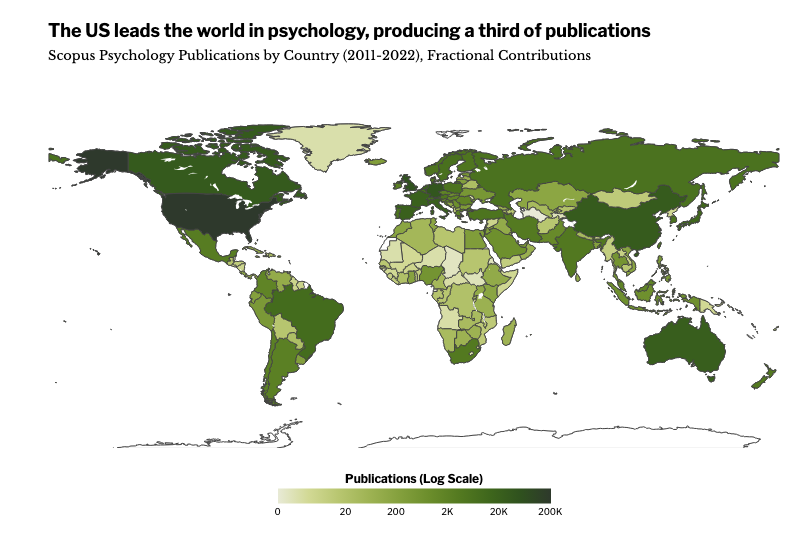

In [11]:
map_scale = MAP_SCALE
low, high = country_summary_11_22['log_publications'].min(), country_summary_11_22['log_publications'].max()

country_summary_11_22['hover_color'] = country_summary_11_22['log_publications'].map(
    lambda x: gradient_color(x, map_scale, low, high))
country_summary_11_22['pub_share_world'] = (country_summary_11_22['Publications'] / world_total_psych).round(6)
country_summary_11_22['pop_share_world'] = (country_summary_11_22['Population'] / world_pop).round(6)

pub_ticks = [0, 20, 200, 2000, 20000, 200000]

map_fig = go.Figure(go.Choropleth(
    locations=country_summary_11_22['iso_alpha'].tolist(),
    locationmode='ISO-3',
    z=country_summary_11_22['log_publications'].round(4).tolist(),
    colorscale=map_scale,
    customdata=country_summary_11_22[['Country', 'Publications', 'hover_color',
                                'pub_share_world', 'pop_share_world']].values.tolist(),
    hovertemplate="<b>%{customdata[0]} </b>"
                  "<span style='color:%{customdata[2]};vertical-align:middle'>■</span><br>"
                  "%{customdata[1]:,} publications<br>"
                  "%{customdata[3]:.1%} of world publications<br>"
                  "%{customdata[4]:.1%} of world population<extra></extra>",
    colorbar=dict(
        orientation='h', x=0.5, y=-0.12, xanchor='center', yanchor='middle',
        len=0.4, thickness=15, outlinewidth=0, ticks="",
        tickvals=[round(float(np.log1p(v)), 4) for v in pub_ticks],
        ticktext=[short_number(v) for v in pub_ticks],
        tickfont=dict(family=SANS, size=9, color="black"),
        title=dict(text="<b>Publications (Log Scale)</b>", side="top",
                   font=dict(family=SANS, size=12, color="black")),
    ),
))

map_fig.update_geos(showcountries=True, countrycolor="lightgray", countrywidth=0.5,
                    landcolor=BG, showframe=False, bgcolor=BG, fitbounds="locations")

map_fig.update_layout(
    # l=0 so the map starts flush with the text column
    # colorbar is placed in paper coords at x=0.5 to stay centered
    autosize=True, paper_bgcolor=BG, margin=dict(t=0, b=80, l=0, r=10, autoexpand=False),
    hoverlabel=HOVER,
)

titled(map_fig,
       "The US leads the world in psychology, producing a third of publications",
       "Scopus Psychology Publications by Country (2011-2022), Fractional Contributions",
       png="main_map.png", height=536, margin=dict(t=80, b=86, l=PAD, r=20), title_top=37)

## Change over time


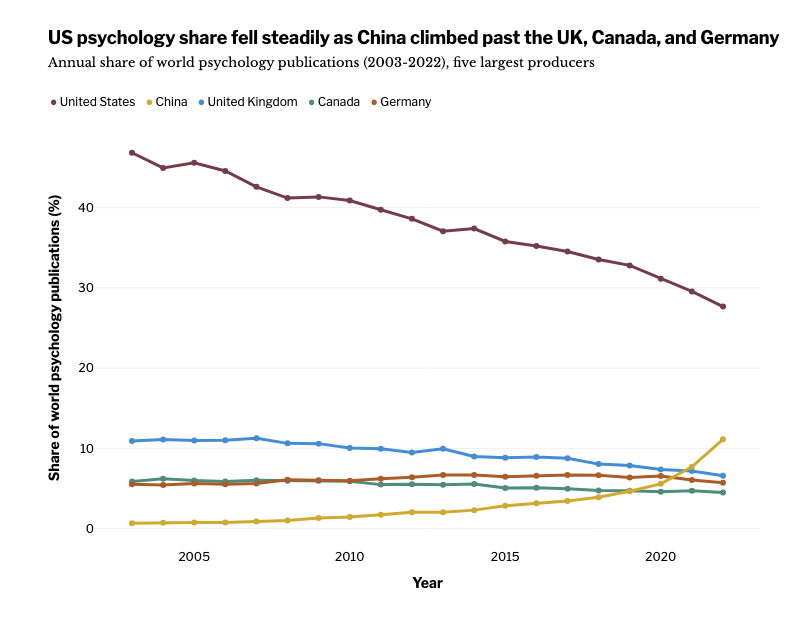

In [12]:
panel_cy = merged_data.groupby(['iso_alpha', 'Country', 'Year'], as_index=False)['Publications'].sum()

world_by_year = panel_cy.groupby('Year')['Publications'].sum()
panel_cy = panel_cy.merge(world_by_year.rename('world_total'), left_on='Year', right_index=True)
panel_cy['share_of_world'] = panel_cy['Publications'] / panel_cy['world_total']

trend_countries = {"USA":"United States", "GBR":"United Kingdom", "CAN":"Canada", "DEU":"Germany", "CHN":"China"}
trend_colors = {"United States": LEAD, 
                "China": ALT, 
                "United Kingdom": UK_C,
                "Canada": CA_C, 
                "Germany": DE_C}
legend_order = ["United States", "China", "United Kingdom", "Canada", "Germany"]

trend_fig = go.Figure()

for iso, name in trend_countries.items():
    sub = panel_cy[panel_cy['iso_alpha'] == iso].sort_values('Year')
    trend_fig.add_trace(go.Scatter(
        x=sub['Year'].tolist(), y=(sub['share_of_world'] * 100).round(4).tolist(),
        mode="lines+markers", name=name, showlegend=False,
        line=dict(color=trend_colors[name], width=3),
        marker=dict(size=6, color=trend_colors[name]),
        hovertemplate=f"<b>{name}</b><br>Year: %{{x}}<br>Share: %{{y:.2f}}%<extra></extra>",
    ))

trend_fig.update_xaxes(title="<b>Year</b>", showgrid=False, zeroline=False, automargin=False,
                       tickfont=dict(family=SANS, size=12))
trend_fig.update_yaxes(title="<b>Share of world psychology publications (%)</b>", showgrid=True,
                       gridcolor=GRID, zeroline=False, automargin=False,
                       tickfont=dict(family=SANS, size=12))

trend_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(family=SANS, size=12, color="black"),
    hoverlabel=HOVER,
    margin=dict(t=20, b=70, l=52, r=20),
)

titled(trend_fig,
       "US psychology share fell steadily as China climbed past the UK, Canada, and Germany",
       "Annual share of world psychology publications (2003-2022), five largest producers",
       legend=[(name, trend_colors[name]) for name in legend_order],
       png="global_share_overtime.png", height=618, margin=dict(t=128, b=70, l=95, r=40), title_top=44)


In [13]:
# WEIRD country list from https://pmc.ncbi.nlm.nih.gov/articles/PMC12852971/
WEIRD = {"United Kingdom", 
         "United States", "Canada", 
         "Italy", 
         "Greece", "Germany", "Denmark", "Australia", 
         "Spain", "Netherlands", "Ireland", "France", 
         "Switzerland", "Belgium", "Sweden", "Norway", 
         "New Zealand", "Finland", "Austria", "Portugal"}

matched = panel_cy[panel_cy['Country'].isin(WEIRD)]['Country'].unique()
missing = WEIRD - set(matched)
assert not missing, f"WEIRD countries not found in Country column: {missing}"

def weird_share(year):
    share = panel_cy.loc[(panel_cy['Country'].isin(WEIRD)) & (panel_cy['Year'] == year),
                        'share_of_world'].sum()

    return float(share) * 100

print(f"Matched all {len(WEIRD)} WEIRD countries")
print(f"WEIRD share was {weird_share(2003):.1f}% in 2003 and {weird_share(2022):.1f}% in 2022")

Matched all 20 WEIRD countries
WEIRD share was 90.6% in 2003 and 67.5% in 2022


### Diversifying by volume, or by share?

The trend above tracks each country's share of world psychology. This tracks something different: how much of each bloc's own science output goes to psychology, which is the measure the WEIRD split is defined on.

In [14]:
top15_names = set(country_summary_11_22.nlargest(15, 'SE_articles_total')['Country'])

def bloc_share(frame, countries):
    """Psychology as a percentage of the science output of `countries`."""
    sel = frame[frame['Country'].isin(countries)]
    return sel['Publications'].sum() / sel['SE_articles_total'].sum() * 100

rows = []
for year in sorted(merged_data['Year'].unique()):
    y = merged_data[merged_data['Year'] == year]
    rows.append({
        'year': year,
        'WEIRD': bloc_share(y, WEIRD),
        'non_WEIRD': bloc_share(y, set(y['Country']) - WEIRD),
        'top15_WEIRD': bloc_share(y, WEIRD & top15_names),
        'top15_non_WEIRD': bloc_share(y, top15_names - WEIRD),
        'world': y['Publications'].sum() / y['SE_articles_total'].sum() * 100,
    })

convergence = pd.DataFrame(rows).set_index('year')
convergence['ratio'] = convergence['WEIRD'] / convergence['non_WEIRD']
convergence['top15_ratio'] = convergence['top15_WEIRD'] / convergence['top15_non_WEIRD']

print("Psychology as a percentage of each bloc's own science output\n")
print(convergence.round(2).to_string())

first, last = convergence.index.min(), convergence.index.max()
print(f"\nall countries: gap {convergence.loc[first, 'ratio']:.1f}x in {first} "
      f"to {convergence.loc[last, 'ratio']:.1f}x in {last}")
print(f"top 15:        gap {convergence.loc[first, 'top15_ratio']:.1f}x in {first} "
      f"to {convergence.loc[last, 'top15_ratio']:.1f}x in {last}")
print(f"widest gap at {convergence['ratio'].idxmax()}, so convergence starts mid-period")

Psychology as a percentage of each bloc's own science output

      WEIRD  non_WEIRD  top15_WEIRD  top15_non_WEIRD  world  ratio  top15_ratio
year                                                                           
2003   2.49       0.46         2.58             0.32   1.76   5.38         8.18
2004   2.46       0.44         2.54             0.31   1.70   5.53         8.29
2005   2.42       0.41         2.51             0.28   1.64   5.84         8.86
2006   2.49       0.42         2.57             0.27   1.65   5.86         9.52
2007   2.54       0.46         2.62             0.30   1.67   5.50         8.88
2008   2.69       0.46         2.74             0.28   1.72   5.89         9.69
2009   2.75       0.45         2.83             0.29   1.72   6.07         9.75
2010   2.82       0.47         2.89             0.31   1.73   6.06         9.42
2011   2.96       0.50         3.01             0.33   1.80   5.91         9.16
2012   3.05       0.58         3.10             0.40   1.8

## Psychology's share of national output

Volume and share answer different questions:
-  Volume is how much of the field a country writes
-  share is how much of that country's research system does the writing


In [15]:
rho = country_summary_11_22[['Publications', 'SE_articles_total']].corr(method='spearman').loc['Publications', 'SE_articles_total']
print(f"Spearman rho = {rho:.3f}")

Spearman rho = 0.957


### Ranked by share

Ranking the 15 largest science producers by psychology's share of national output separates them cleanly on WEIRD status.


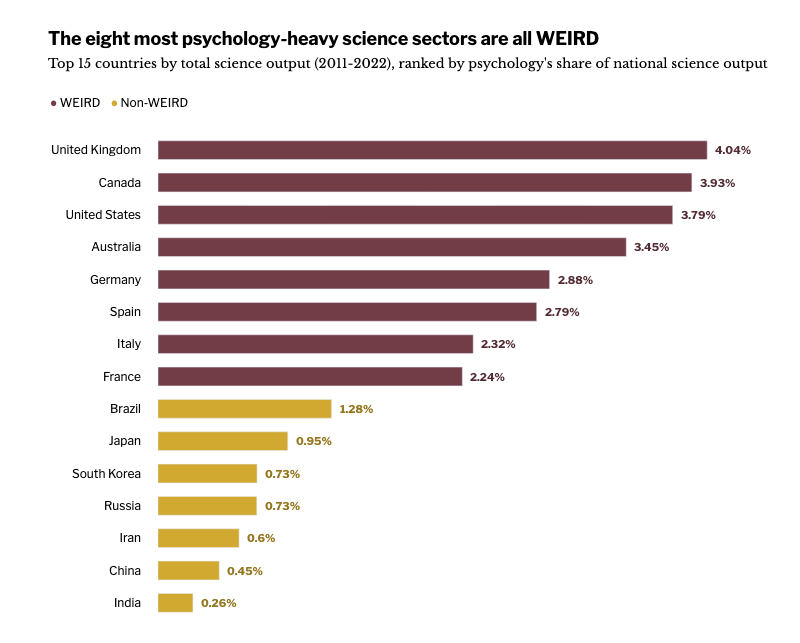

In [ ]:
top_by_share = (country_summary_11_22
                .dropna(subset=['SE_articles_total', 'psych_share'])
                .nlargest(15, 'SE_articles_total')
                .sort_values('psych_share')
                .copy())

WEIRD_COLOR, NONWEIRD_COLOR = LEAD, ALT  # The shared pair from Figure guidelines

color_for = {c: (WEIRD_COLOR if c in WEIRD else NONWEIRD_COLOR) for c in top_by_share['Country']}
colors = [color_for[c] for c in top_by_share['Country']]

rank_fig = go.Figure()

rank_fig.add_trace(go.Bar(
    x=(top_by_share['psych_share'] * 100).round(3).tolist(),
    y=top_by_share['Country'].tolist(),
    orientation='h',
    marker=dict(color=colors),
    showlegend=False,
    hoverinfo="skip",
))

for country, share in zip(top_by_share['Country'], top_by_share['psych_share']):
    rank_fig.add_annotation(
        x=share * 100, y=country, xanchor="left", xshift=6, showarrow=False,
        text=f"<b>{share:.2%}</b>".replace('0%', '%').replace('.0%', '%'),
        font=dict(family=SANS, size=11, color=darken(color_for[country])))

rank_fig.update_xaxes(
    showgrid=False, showticklabels=False, zeroline=False,
    range=[0, top_by_share['psych_share'].max() * 100 * 1.005],
    domain=[0, 1]
    )

rank_fig.update_yaxes(
    showgrid=False, zeroline=False, showspikes=False, ticklabelstandoff=16,
    automargin=False, tickfont=dict(family=SANS, size=12))

rank_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG, bargap=0.42,
    font=dict(family=SANS, size=12, color="black"),
    # l measured for longest label "United Kingdom"; b is small because the
    # x-axis is hidden, so no tick labels or axis title need room below
    hoverlabel=HOVER, margin=dict(t=20, b=20, l=109, r=51))

titled(rank_fig,
       "The eight most psychology-heavy science sectors are all WEIRD",
       "Top 15 countries by total science output (2011-2022), ranked by psychology's share of national science output",
       legend=[("WEIRD", WEIRD_COLOR), ("Non-WEIRD", NONWEIRD_COLOR)],
       png="psych_share_ranked.png", height=643, margin=dict(t=134, b=24, l=158, r=90), title_top=45)


### Volume against share


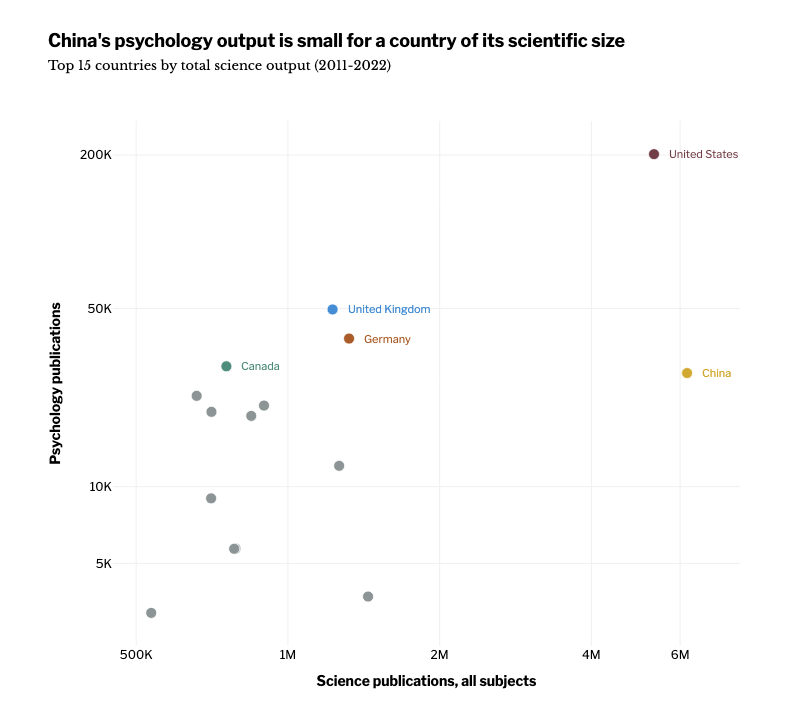

In [ ]:
top = (country_summary_11_22
       .dropna(subset=['SE_articles_total', 'psych_share'])
       .nlargest(15, 'SE_articles_total')
       .copy())

# Same colour per country as the trend chart; the other ten sit in FAINT
HILITE = {'United States': LEAD,
          'China': ALT,
          'United Kingdom': UK_C,
          'Canada': CA_C,
          'Germany': DE_C}

scatter_fig = go.Figure()

scatter_fig.add_trace(go.Scatter(
    x=top['SE_articles_total'].tolist(),
    y=top['Publications'].tolist(),
    mode="markers", showlegend=False,
    marker=dict(size=11, line=dict(width=0.8, color="white"),
                color=[HILITE.get(c, FAINT) for c in top['Country']]),
    customdata=top[['Country', 'psych_share']].values.tolist(),
    hovertemplate=("<b>%{customdata[0]}</b><br>"
                   "%{x:,.0f} science publications<br>"
                   "%{y:,.0f} psychology publications<br><extra></extra>")))

LABELLED = set(HILITE)

for _, r in top[top['Country'].isin(LABELLED)].iterrows():
    scatter_fig.add_annotation(
        x=np.log10(r['SE_articles_total']), y=np.log10(r['Publications']),
        text=r['Country'], showarrow=False, xanchor="left", xshift=13,
        font=dict(family=SANS, size=11, color=HILITE.get(r['Country'], FAINT)))

scatter_fig.update_xaxes(
    type="log", title="<b>Science publications, all subjects</b>",
    showgrid=True, gridcolor=GRID, zeroline=False,
    tickvals=[5e5, 1e6, 2e6, 4e6, 6e6],
    ticktext=[short_number(v) for v in [5e5, 1e6, 2e6, 4e6, 6e6]],
    tickfont=dict(family=SANS, size=12))

scatter_fig.update_yaxes(
    type="log", title="<b>Psychology publications</b>",
    showgrid=True, gridcolor=GRID, zeroline=False,
    tickvals=[2e3, 5e3, 1e4, 5e4, 2e5],
    ticktext=[short_number(v) for v in [2e3, 5e3, 1e4, 5e4, 2e5]],
    tickfont=dict(family=SANS, size=12))

scatter_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(family=SANS, size=12, color="black"),
    # l as in trend_fig, but wider tick labels ("200K") need more room
    hoverlabel=HOVER, margin=dict(t=30, b=55, l=70, r=40))

titled(scatter_fig,
       "China's psychology output is small for a country of its scientific size",
       "Top 15 countries by total science output (2011-2022)",
       png="science_vs_psych_scatter.png", height=721, margin=dict(t=121, b=75, l=113, r=60), title_top=47)

# China's psychology output is small for a country of its scientific size

In [ ]:
# The UK/Japan pair: matched on science output, income and 
# education, so the psychology difference is not a difference 
# in scale or in research capacity
pair_cols = ['SE_articles_total', 'Publications', 'psych_share', 'GDP_per_capita',
             'Tertiary_enrollment_pct', 'Researchers_per_million', 'Urban_population_pct']

pair = country_summary_11_22.set_index('Country').loc[['United Kingdom', 'Japan'], pair_cols]
print(pair.round(3).to_string())

uk, jp = pair.loc['United Kingdom'], pair.loc['Japan']
print(f"\nUK science / Japan science:       {uk['SE_articles_total'] / jp['SE_articles_total']:.2f}x")
print(f"UK psychology / Japan psychology: {uk['Publications'] / jp['Publications']:.2f}x")

                SE_articles_total  Publications  psych_share  GDP_per_capita  Tertiary_enrollment_pct  Researchers_per_million  Urban_population_pct
Country                                                                                                                                             
United Kingdom         1226434.09      49574.46         0.04       43848.507                   63.212                 4248.647                 82.14
Japan                  1263777.51      12068.66         0.01       41262.383                   62.643                 5318.917                 91.47

UK science / Japan science:       0.97x
UK psychology / Japan psychology: 4.11x


## Predictors of psychology's share

Does national income explain how much of a research system goes to psychology? Below: distribution checks, then a Poisson model that keeps the zero-publication countries in.


### Distribution checks


In [19]:
base = country_summary.dropna(subset=['SE_articles_total']).copy()
print("Country totals, 2003-2022\n")
print(base[['Publications', 'SE_articles_total', 'psych_share']].describe().round(4).to_string())

Country totals, 2003-2022

       Publications  SE_articles_total  psych_share
count      201.0000       2.010000e+02     201.0000
mean      4056.7460       2.162312e+05       0.0141
std      22347.5618       8.697918e+05       0.0202
min          0.0000       4.660000e+00       0.0000
25%          6.1900       6.330000e+02       0.0048
50%         39.8400       5.341240e+03       0.0101
75%        594.9700       8.165708e+04       0.0179
max     296045.2000       8.419082e+06       0.2260


In [20]:
# Funnel diagnostic: psych_share is a ratio, so countries with small
# denominators vary more by construction than by behavior

base['granularity'] = 1 / base['SE_articles_total']
base['den_decile'] = pd.qcut(base['SE_articles_total'], 10, labels=False)

spread = base.groupby('den_decile').agg(
    n=('psych_share', 'size'),
    den_max=('SE_articles_total', 'max'),
    granularity=('granularity', 'median'),
    share_sd=('psych_share', 'std'),
    share_iqr=('psych_share', lambda x: x.quantile(.75) - x.quantile(.25)),
).round(5)

spread['granularity_ratio'] = spread['granularity'] / spread['share_sd']

print("Spread in psych_share by denominator decile\n")
print(spread.to_string())

Spread in psych_share by denominator decile

             n     den_max  granularity  share_sd  share_iqr  granularity_ratio
den_decile                                                                     
0           21      146.03      0.01760   0.05233    0.01078           0.336327
1           20      307.59      0.00451   0.02286    0.01586           0.197288
2           20     1109.49      0.00156   0.00779    0.00731           0.200257
3           20     2260.62      0.00059   0.00834    0.01076           0.070743
4           20     5341.24      0.00029   0.00683    0.00899           0.042460
5           20    13143.45      0.00010   0.00924    0.01624           0.010823
6           20    44374.84      0.00004   0.00776    0.00648           0.005155
7           20   160320.78      0.00001   0.01009    0.01404           0.000991
8           20   385289.99      0.00000   0.01161    0.01658           0.000000
9           20  8419082.31      0.00000   0.01298    0.01945           0.00

In [21]:
# smallest denominator decile where measurement granularity is small relative
# to the spread in psych_share; applied only to the correlation matrix below
THRESHOLD = 1500
country_summary_noise_cutoff = base[(base['SE_articles_total'] >= THRESHOLD) &
                                    (base['Publications'] > 0)]
print(f"n = {len(country_summary_noise_cutoff)}")

n = 132


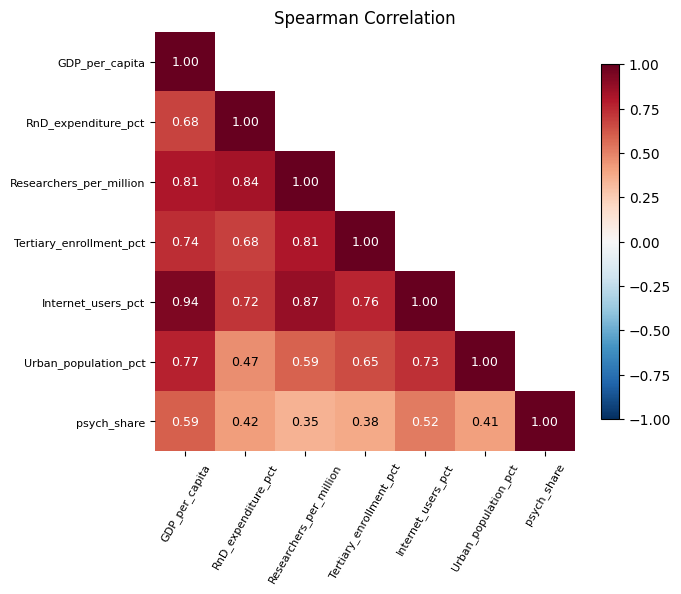

In [22]:
preds = ['GDP_per_capita', 
         'RnD_expenditure_pct',
         'Researchers_per_million', 
         'Tertiary_enrollment_pct',
         'Internet_users_pct', 
         'Urban_population_pct',
         'psych_share']

sub = country_summary_noise_cutoff[preds].dropna()
spear = sub.corr(method='spearman')
spear_masked = spear.where(np.tril(np.ones(spear.shape)).astype(bool))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(spear_masked, cmap='RdBu_r', vmin=-1, vmax=1, origin='upper')

ax.set_xticks(range(len(spear)))
ax.set_xticklabels(spear.columns, rotation=60, fontsize=8)
ax.set_yticks(range(len(spear)))
ax.set_yticklabels(spear.columns, fontsize=8)
ax.set_title('Spearman Correlation')

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(len(spear)):
    for j in range(len(spear)):
        val = spear_masked.iloc[i, j]
        if pd.notna(val):
            val = float(val) # type: ignore
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(val) > 0.5 else "black")

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

In [23]:
# the values behind the heatmap, and the sample the screen actually runs on:
# THRESHOLD drops small denominators, then dropna drops rows missing any predictor
screen = spear['psych_share'].drop('psych_share').sort_values(ascending=False)
with_income = spear['GDP_per_capita'].drop(['GDP_per_capita', 'psych_share'])

print(f"Screen runs on {len(sub)} countries, of {len(country_summary_noise_cutoff)} "
      f"above the {THRESHOLD:,}-publication cutoff\n")
print(f"{'predictor':26s} {'vs psych_share':>15s} {'vs GDP_per_capita':>19s}")
for name, rho_share in screen.items():
    rho_income = with_income.get(name)
    income_col = f"{rho_income:19.3f}" if pd.notna(rho_income) else f"{'':>19s}"
    print(f"{name:26s} {rho_share:15.3f}{income_col}")

Screen runs on 115 countries, of 132 above the 1,500-publication cutoff

predictor                   vs psych_share   vs GDP_per_capita
GDP_per_capita                       0.595                   
Internet_users_pct                   0.518              0.937
RnD_expenditure_pct                  0.418              0.677
Urban_population_pct                 0.407              0.772
Tertiary_enrollment_pct              0.378              0.738
Researchers_per_million              0.346              0.811


1,173 of 4,020 country-year observations are zero (29.2%), 100 of which have no GDP per capita data


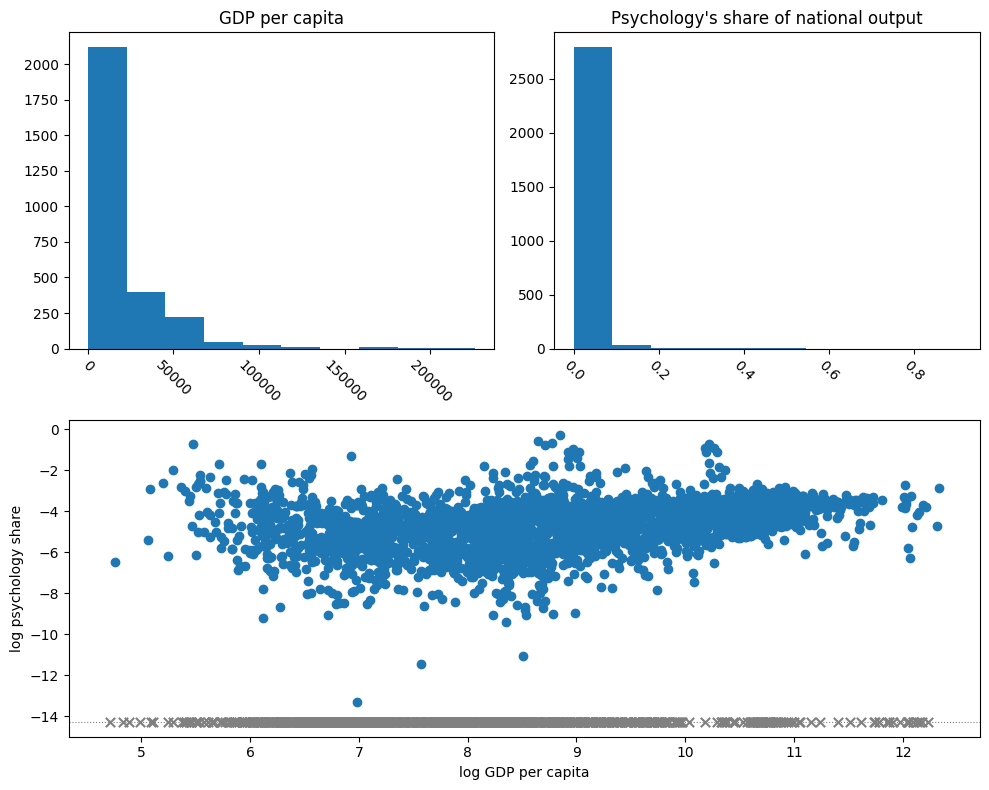

In [24]:
merged_data['psych_share'] = merged_data['Publications'] / merged_data['SE_articles_total']
merged_data_nonzero = merged_data[merged_data['Publications'] > 0]
merged_data_zeros = merged_data[merged_data['Publications'] == 0].dropna(subset=['GDP_per_capita'])

n_zero = (merged_data['Publications'] == 0).sum()
print(f"{n_zero:,} of {len(merged_data):,} country-year observations are zero "
      f"({n_zero / len(merged_data):.1%})"
      f", {len(merged_data[merged_data['Publications'] == 0]) - len(merged_data_zeros)} of which have no GDP per capita data")


fig = plt.figure(figsize=(10,8))

ax1 = plt.subplot2grid((2, 2), (0,0))
ax1.hist(merged_data_nonzero['GDP_per_capita'])
ax1.set_title('GDP per capita')

ax2 = plt.subplot2grid((2, 2), (0,1))
ax2.hist(merged_data_nonzero['psych_share'])
ax2.set_title("Psychology's share of national output")

ax3 = plt.subplot2grid((2, 2), (1,0), colspan=2)

x = np.asarray(np.log(merged_data_nonzero['GDP_per_capita']))
y = np.asarray(np.log(merged_data_nonzero['psych_share']))
ax3.scatter(x, y)
ax3.set_xlabel('log GDP per capita')
ax3.set_ylabel('log psychology share')
floor = y.min() - 1.0
ax3.scatter(np.log(merged_data_zeros['GDP_per_capita']), [floor] * len(merged_data_zeros),
            marker='x', s=45, color='gray')
ax3.axhline(floor, color='gray', lw=0.8, ls=':')
ax3.text(x.min(), floor + 0.25, f'{len(merged_data_zeros)} countries with zero psychology publications '
         '— undefined in logs', fontsize=8, color='gray')

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=-45)

plt.tight_layout()

The dependent variable has a mass of zeros that logs cannot take, and the variance grows with the mean. Both rule out OLS on a logged share, so the models below use Poisson pseudo-maximum likelihood with total S&E output as an offset.


### Panel setup

model estimates psychology per unit of science output

In [ ]:
# The denominator cutoff used for the correlations above is dropped here:
# PPML handles small denominators and zeros directly
panel = merged_data.dropna(subset=['GDP_per_capita', 'SE_articles_total']).copy()
panel = panel[panel['SE_articles_total'] > 0].copy()

panel['log_gdp'] = np.log(panel['GDP_per_capita'])
panel['offset'] = np.log(panel['SE_articles_total'])

print(f"Panel: {len(panel)} country-years, {panel['iso_alpha'].nunique()} countries, "
      f"{panel['Year'].min()}-{panel['Year'].max()}")
print(f"Zero-publication country-years retained: {(panel['Publications'] == 0).sum()} "
      f"({(panel['Publications'] == 0).mean():.1%}) ")

balance = panel.groupby('Year').size()
print(f"Country-years per year: min {balance.min()} ({balance.idxmin()}), "
      f"max {balance.max()} ({balance.idxmax()})")

zero_by_country = panel.groupby('iso_alpha')['Publications'].apply(lambda x: (x == 0).mean())
print("\nHighest share of zero-publication years, by country:")
print(zero_by_country.sort_values(ascending=False).head(20))

Panel: 3879 country-years, 197 countries, 2003-2022
Zero-publication country-years retained: 1046 (27.0%) 
Country-years per year: min 191 (2005), max 196 (2009)

Highest share of zero-publication years, by country:
iso_alpha
GNQ    1.000000
PLW    1.000000
STP    1.000000
FSM    1.000000
DJI    1.000000
TLS    1.000000
KIR    1.000000
NRU    1.000000
MHL    1.000000
VUT    0.950000
LCA    0.950000
MDV    0.950000
SLB    0.950000
TKM    0.950000
COM    0.950000
TUV    0.941176
ATG    0.900000
WSM    0.900000
AND    0.900000
ERI    0.888889
Name: Publications, dtype: float64


### Offset check

Total S&E output enters as an offset, which forces its coefficient to 1.

In [26]:
year_dummies = pd.get_dummies(panel['Year'], prefix='yr', drop_first=True, dtype=float)

Xp_unrestricted = sm.add_constant(pd.concat(
    [panel[['log_gdp', 'offset']].rename(columns={'offset': 'log_total'}), year_dummies], axis=1
))
ppml_unrestricted = sm.GLM(panel['Publications'], Xp_unrestricted, family=sm.families.Poisson()).fit(
    cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

b = ppml_unrestricted.params['log_total']
se = ppml_unrestricted.bse['log_total']
print(f"unrestricted log_total coef: {b:.3f} (se {se:.3f})")
print(f"test coef == 1: z = {(b - 1) / se:.2f}")

unrestricted log_total coef: 0.997 (se 0.047)
test coef == 1: z = -0.06


### Model 1: income, year fixed effects

Year effects absorb any influences on the globe, such as Scopus widening its coverage.


In [27]:
# without year fixed effects
X_plain = sm.add_constant(panel[['log_gdp']])
ppml_plain = sm.GLM(
    panel['Publications'], X_plain, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

# with year fixed effects
X_year = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies], axis=1))
ppml_year = sm.GLM(
    panel['Publications'], X_year, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

print(f"log_gdp, no year FE  : {ppml_plain.params['log_gdp']:.3f} (se {ppml_plain.bse['log_gdp']:.3f})")
print(f"log_gdp, with year FE: {ppml_year.params['log_gdp']:.3f} (se {ppml_year.bse['log_gdp']:.3f})")

log_gdp, no year FE  : 0.826 (se 0.106)
log_gdp, with year FE: 0.826 (se 0.109)


In [28]:
# the coefficient as an effect size: a doubling of income is +1 on log2 scale,
# so 2**b - 1 is the proportional change in psychology per unit of science output
b, se = ppml_year.params['log_gdp'], ppml_year.bse['log_gdp']
lo, hi = b - 1.96 * se, b + 1.96 * se

print(f"log_gdp = {b:.3f} (se {se:.3f}), z = {b / se:.2f}")
print(f"per doubling of GDP per capita: {(2 ** b - 1) * 100:.0f}% more psychology "
      f"(95% CI {(2 ** lo - 1) * 100:.0f}% to {(2 ** hi - 1) * 100:.0f}%)")

log_gdp = 0.826 (se 0.109), z = 7.57
per doubling of GDP per capita: 77% more psychology (95% CI 53% to 106%)


### Model 2: adding country fixed effects

Country effects strip out the between-country ranking, leaving only variation within a country over time.


In [29]:
country_dummies = pd.get_dummies(panel['iso_alpha'], prefix='c', drop_first=True, dtype=float)

X_country = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies, country_dummies], axis=1))
ppml_country = sm.GLM(
    panel['Publications'], X_country, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

print(f"log_gdp, year FE only   : {ppml_year.params['log_gdp']:.3f} (se {ppml_year.bse['log_gdp']:.3f})")
print(f"log_gdp, with country FE: {ppml_country.params['log_gdp']:.3f} (se {ppml_country.bse['log_gdp']:.3f})")

log_gdp, year FE only   : 0.826 (se 0.109)
log_gdp, with country FE: 0.252 (se 0.251)


Country fixed effects drop the income coefficient from 0.83 to 0.25, with a standard error about as large. The gradient is almost entirely between countries: richer countries devote more of their research systems to psychology, but a country growing richer does not measurably shift its own. Dispersion far exceeds the Poisson assumption in both specifications, which is why every model is fit with standard errors clustered by country.


### Model 3: income x year trend

Interacting income with a year trend asks whether the gradient itself is changing.


In [30]:
panel['log_gdp_x_trend'] = panel['log_gdp'] * (panel['Year'] - 2011)
base_cols = panel[['log_gdp', 'log_gdp_x_trend']]

specs = {
    'year FE only (between-country)': [base_cols, year_dummies],
    'adding country FE (within-country)': [base_cols, year_dummies, country_dummies],
}

trend_fits = {}
for label, parts in specs.items():
    f = sm.GLM(panel['Publications'], sm.add_constant(pd.concat(parts, axis=1)),
               family=sm.families.Poisson(), offset=panel['offset']
              ).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})
    trend_fits[label] = f
    print(f"\n{label}")
    print(f"  log_gdp (at 2011): {f.params['log_gdp']:.3f} (se {f.bse['log_gdp']:.3f})")
    print(f"  log_gdp x year trend: {f.params['log_gdp_x_trend']:.3f} "
          f"(se {f.bse['log_gdp_x_trend']:.3f}), z = "
          f"{f.params['log_gdp_x_trend'] / f.bse['log_gdp_x_trend']:.2f}")

ppml_trend = trend_fits['year FE only (between-country)']
b_main, b_trend = ppml_trend.params['log_gdp'], ppml_trend.params['log_gdp_x_trend']

print("\nImplied income gradient (year FE only):")
for year in [2003, 2009, 2011, 2016, 2022]:
    effect = b_main + b_trend * (year - 2011)
    print(f"  {year}: {effect:.3f}  ({(2**effect - 1) * 100:.0f}% more psych output per GDP doubling)")


year FE only (between-country)
  log_gdp (at 2011): 0.904 (se 0.107)
  log_gdp x year trend: -0.016 (se 0.007), z = -2.18



adding country FE (within-country)
  log_gdp (at 2011): 0.176 (se 0.134)
  log_gdp x year trend: -0.024 (se 0.005), z = -4.53

Implied income gradient (year FE only):
  2003: 1.030  (104% more psych output per GDP doubling)
  2009: 0.935  (91% more psych output per GDP doubling)
  2011: 0.904  (87% more psych output per GDP doubling)
  2016: 0.825  (77% more psych output per GDP doubling)
  2022: 0.731  (66% more psych output per GDP doubling)


The income gradient flattens over time: a GDP doubling bought more psychology output in 2003 than in 2022, consistent with the widening contributor base in the time series above.


### Model comparison


In [31]:
models = {
    "1  income + year FE": ppml_year,
    "2  + country FE": ppml_country,
    "3  income x year trend": ppml_trend,
}

print(f"{'model':24s} {'log_gdp':>8s} {'se':>7s} {'chi2/df':>8s} {'converged':>10s}")
for label, fit in models.items():
    print(f"{label:24s} {fit.params['log_gdp']:8.3f} {fit.bse['log_gdp']:7.3f} "
          f"{fit.pearson_chi2 / fit.df_resid:8.2f} {str(fit.converged):>10s}")

model                     log_gdp      se  chi2/df  converged
1  income + year FE         0.826   0.109    47.79       True
2  + country FE             0.252   0.251     6.30       True
3  income x year trend      0.904   0.107    51.21       True


### Country residuals

Model 1's fitted values against actual output, summed over 2011-2022 so the comparison lines up with the cross-sectional window used above.

In [32]:
panel['fitted'] = ppml_year.fittedvalues

resid = (panel[panel['Year'].between(2011, 2022)]
         .groupby('Country')
         .agg(actual=('Publications', 'sum'), predicted=('fitted', 'sum')))
resid['vs_predicted_pct'] = (resid['actual'] / resid['predicted'] - 1) * 100

top15 = country_summary_11_22.nlargest(15, 'SE_articles_total').set_index('Country')
top15_resid = resid.loc[resid.index.intersection(top15.index)].copy()
top15_resid['psych_share_pct'] = top15['psych_share'] * 100
top15_resid['WEIRD'] = ['WEIRD' if c in WEIRD else 'non-WEIRD' for c in top15_resid.index]

print("Actual against Model 1's prediction, 2011-2022\n")
print(top15_resid.sort_values('vs_predicted_pct', ascending=False)
      [['WEIRD', 'psych_share_pct', 'actual', 'predicted', 'vs_predicted_pct']]
      .round(2).to_string())

for label in ['WEIRD', 'non-WEIRD']:
    group = top15_resid.loc[top15_resid['WEIRD'] == label, 'vs_predicted_pct']
    print(f"\n{label} residual range: {group.min():.0f}% to {group.max():.0f}%")

Actual against Model 1's prediction, 2011-2022

                    WEIRD  psych_share_pct     actual  predicted  vs_predicted_pct
Country                                                                           
Brazil          non-WEIRD             1.28    8994.62    5471.49             64.39
United Kingdom      WEIRD             4.04   49574.46   32939.29             50.50
Spain               WEIRD             2.79   19654.50   13494.27             45.65
Canada              WEIRD             3.93   29663.27   22107.28             34.18
Iran            non-WEIRD             0.60    3196.37    2469.81             29.42
India           non-WEIRD             0.26    3704.69    2912.95             27.18
United States       WEIRD             3.79  201664.58  187727.46              7.42
Italy               WEIRD             2.32   20801.63   19729.92              5.43
Germany             WEIRD             2.88   38102.80   37719.28              1.02
Australia           WEIRD             3

### Do the WEIRD traits separate the top 15?

The screen above tests the predictors across all countries. This asks a narrower question: within the fifteen largest science producers, does any single measure divide the WEIRD group from the rest the way psychology's share does?

In [ ]:
traits = ['GDP_per_capita', 'Tertiary_enrollment_pct', 'Researchers_per_million',
          'RnD_expenditure_pct', 'Internet_users_pct', 'Urban_population_pct']

top15_traits = country_summary_11_22.nlargest(15, 'SE_articles_total').set_index('Country')
top15_traits['psych_share_pct'] = top15_traits['psych_share'] * 100
is_weird = top15_traits.index.isin(list(WEIRD))

# A measure separates the two groups only if its lowest WEIRD value still
# exceeds its highest non-WEIRD value
print(f"{'measure':24s} {'lowest WEIRD':>28s} {'highest non-WEIRD':>28s}  separates?")
for col in traits + ['psych_share_pct']:
    weird_vals = top15_traits.loc[is_weird, col].dropna()
    other_vals = top15_traits.loc[~is_weird, col].dropna()
    lo_w, hi_o = weird_vals.min(), other_vals.max()
    left = f"{weird_vals.idxmin()} {lo_w:,.1f}"
    right = f"{other_vals.idxmax()} {hi_o:,.1f}"
    print(f"{col:24s} {left:>28s} {right:>28s}  {'yes' if lo_w > hi_o else 'no'}")

ranks = top15_traits[traits + ['psych_share_pct']].rank(ascending=False)
print("\nSouth Korea's rank of 15 on each measure (1 = highest):")
print(ranks.loc['South Korea'].round(0).astype(int).to_string())

measure                                  lowest WEIRD            highest non-WEIRD  separates?
GDP_per_capita                         Spain 29,089.9               Japan 41,262.4  no
Tertiary_enrollment_pct           United Kingdom 63.2             South Korea 96.6  no
Researchers_per_million                 Italy 2,277.3          South Korea 7,544.3  no
RnD_expenditure_pct                         Spain 1.3              South Korea 4.1  no
Internet_users_pct                         Italy 65.0             South Korea 91.8  no
Urban_population_pct                       Italy 69.4                   Japan 91.5  no
psych_share_pct                            France 2.2                   Brazil 1.3  yes

South Korea's rank of 15 on each measure (1 = highest):
GDP_per_capita              9
Tertiary_enrollment_pct     2
Researchers_per_million     1
RnD_expenditure_pct         1
Internet_users_pct          1
Urban_population_pct        6
psych_share_pct            11


## Export

Generate `docs/js/chart-data.js` for `docs/index.html`.


In [34]:
write_chart_data({"c1": map_fig, "c2": rank_fig, "c3": trend_fig, "c4": scatter_fig})

wrote ../docs/js/chart-data.js (32,985 bytes)


## What this all means

Psychology's contributor base is more distributed between WEIRD and non-WEIRD countries than it was twenty years ago, but what psychology says is still overwhelmingly written inside WEIRD research systems.

1. **Volume is diversifying.** The US share of world psychology nearly halved since 2003, and China now ranks second in annual output.
2. **Share is diversifying, albeit slower than volume.** WEIRD research systems devoted more than five times as much of their science to psychology as non-WEIRD ones in 2003; by 2022 that gap had narrowed to about three and a half times. It widened through 2009 before it began to close.
3. **Resources don't explain the divide.** None of the six standard measures of wealth, education, or research and innovation capacity separates the two groups among the top 15 producers, and the measures closest to research capability do the worst. Country fixed effects absorb the income gradient almost entirely: countries that grew richer between 2003 and 2022 did not measurably shift their psychology share.

Figures are written to `figures/` and the interactive versions to `docs/js/chart-data.js`, rendered in the [write-up](https://emilinelabbe.github.io/who-decides-what-psych-says/).